In [11]:
import sys
print(sys.executable)

c:\Users\User\AppData\Local\Programs\Python\Python314\python.exe


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from sklearn.metrics import cohen_kappa_score

In [13]:
df = pd.read_csv("../data/processed/merged_annotations.csv")

# Pairwise Agreement

Cohen’s Kappa gốc chỉ hỗ trợ 2 annotators.

Vì vậy với 3 annotators, ta sẽ tính theo từng cặp:

1. huy vs ngan
2. huy vs choe
3. ngan vs choe

In [14]:
pairs = [
    ('label_huy', 'label_ngan'),
    ('label_huy', 'label_choe'),
    ('label_ngan', 'label_choe')
]

pairs

[('label_huy', 'label_ngan'),
 ('label_huy', 'label_choe'),
 ('label_ngan', 'label_choe')]

# Manual Cohen's Kappa

Công thức:

- Observed Agreement (Po)
- Expected Agreement (Pe)

Sau đó:

kappa = (Po - Pe) / (1 - Pe)

In [15]:
def manual_cohen_kappa(y1, y2):

    # Lấy toàn bộ labels xuất hiện
    labels = sorted(list(set(y1) | set(y2)))

    # Tạo confusion matrix
    cm = confusion_matrix(
        y1,
        y2,
        labels=labels
    )

    total = cm.sum()


    # TÍNH Po
   
    diagonal_sum = np.trace(cm)

    Po = diagonal_sum / total


    # TÍNH Pe
   
    row_totals = cm.sum(axis=1)
    col_totals = cm.sum(axis=0)

    Pe = 0

    for i in range(len(labels)):

        p_a = row_totals[i] / total
        p_b = col_totals[i] / total

        Pe += p_a * p_b

   
    # TÍNH KAPPA

    kappa = (Po - Pe) / (1 - Pe)

    return {
        'labels': labels,
        'confusion_matrix': cm,
        'Po': Po,
        'Pe': Pe,
        'kappa': kappa
    }

# Pairwise Kappa for All Annotators

Ta sẽ tính Cohen’s Kappa cho toàn bộ cặp annotators.

In [16]:
pairwise_results = []

for a1, a2 in pairs:

    result = manual_cohen_kappa(
        df[a1],
        df[a2]
    )

    pairwise_results.append({
        'Annotator 1': a1,
        'Annotator 2': a2,
        'Kappa': round(result['kappa'], 4),
        'Po': round(result['Po'], 4),
        'Pe': round(result['Pe'], 4)
    })

pairwise_df = pd.DataFrame(pairwise_results)

pairwise_df

,Annotator 1,Annotator 2,Kappa,Po,Pe
0,label_huy,label_ngan,0.5004,0.6733,0.3460
1,label_huy,label_choe,0.6381,0.7624,0.3434
2,label_ngan,label_choe,0.7583,0.8416,0.3445


# Average Pairwise Kappa


Công thức tính trung bình pairwise kappa:

$$
\bar{\kappa} = \frac{\kappa_1 + \kappa_2 + \kappa_3}{3}
$$

Trong đó:

- $\kappa_1$: Kappa giữa huy và ngan
- $\kappa_2$: Kappa giữa huy và choe
- $\kappa_3$: Kappa giữa ngan và choe

Công thức này giúp đánh giá overall agreement giữa nhiều annotators.

In [17]:
average_kappa = pairwise_df['Kappa'].mean()

print("Average Pairwise Kappa:")
print(round(average_kappa, 4))

Average Pairwise Kappa:
0.6323


In [18]:
def interpret_kappa(kappa):

    if kappa < 0:
        return "Poor"

    elif kappa <= 0.20:
        return "Slight"

    elif kappa <= 0.40:
        return "Fair"

    elif kappa <= 0.60:
        return "Moderate"

    elif kappa <= 0.80:
        return "Substantial"

    else:
        return "Almost Perfect"

In [19]:
pairwise_df['Interpretation'] = pairwise_df['Kappa'].apply(
    interpret_kappa
)

pairwise_df

,Annotator 1,Annotator 2,Kappa,Po,Pe,Interpretation
0,label_huy,label_ngan,0.5004,0.6733,0.3460,Moderate
1,label_huy,label_choe,0.6381,0.7624,0.3434,Substantial
2,label_ngan,label_choe,0.7583,0.8416,0.3445,Substantial


# Disagreement Analysis

Ta sẽ tìm các samples mà annotators không đồng ý với nhau.

In [20]:
disagreement_results = {}

for a1, a2 in pairs:

    disagreement_df = df[
        df[a1] != df[a2]
    ]

    key = f"{a1}_vs_{a2}"

    disagreement_results[key] = disagreement_df


    print(f"Disagreement: {a1} vs {a2}")
    print(f"Number of disagreements: {len(disagreement_df)}")
    print()

    display(
        disagreement_df.head()
    )

Disagreement: label_huy vs label_ngan
Number of disagreements: 33



,id,data,label_huy,label_ngan,label_choe
15,16,"2 pha quét sạch, 1 pha 5k dame, 1 pha 10k dame...",positive,neutral,positive
16,17,mấy đứa chê Guma đúng ếch😌 chỉ thấy bề nổi của...,positive,neutral,neutral
17,18,ngầm ý bảo thằng zeus không hy sinh thì hơn cả...,positive,negative,negative
18,19,ván 1 oánh max ping nên ván 2 chill chill đẩy ...,positive,neutral,positive
21,22,Năm ngoái thấy tội nhóc này nhất luôn. Smash v...,neutral,positive,positive


Disagreement: label_huy vs label_choe
Number of disagreements: 24



,id,data,label_huy,label_ngan,label_choe
16,17,mấy đứa chê Guma đúng ếch😌 chỉ thấy bề nổi của...,positive,neutral,neutral
17,18,ngầm ý bảo thằng zeus không hy sinh thì hơn cả...,positive,negative,negative
20,21,Hôm qua tui chơi gem xong ngủ luôn tới trưa na...,positive,positive,neutral
21,22,Năm ngoái thấy tội nhóc này nhất luôn. Smash v...,neutral,positive,positive
28,29,Xin lỗi vì đã kệ mẹ thay vì đi def cho thằng a...,neutral,negative,negative


Disagreement: label_ngan vs label_choe
Number of disagreements: 16



,id,data,label_huy,label_ngan,label_choe
15,16,"2 pha quét sạch, 1 pha 5k dame, 1 pha 10k dame...",positive,neutral,positive
18,19,ván 1 oánh max ping nên ván 2 chill chill đẩy ...,positive,neutral,positive
20,21,Hôm qua tui chơi gem xong ngủ luôn tới trưa na...,positive,positive,neutral
22,23,"Tính ra cái câu joke đó hài vcc, mà chắc mẹ bĩ...",negative,neutral,negative
23,24,"Cắt tóc đẹp trai, trẻ trâu v mà 😭",positive,neutral,positive


In [21]:
for key, disagreement_df in disagreement_results.items():

    output_path = f"../outputs/{key}_disagreement.csv"

    disagreement_df.to_csv(
        output_path,
        index=False
    )

    print(f"Saved: {output_path}")

Saved: ../outputs/label_huy_vs_label_ngan_disagreement.csv
Saved: ../outputs/label_huy_vs_label_choe_disagreement.csv
Saved: ../outputs/label_ngan_vs_label_choe_disagreement.csv


In [22]:
total_samples = len(df)

for key, disagreement_df in disagreement_results.items():

    disagreement_rate = (
        len(disagreement_df) / total_samples
    ) * 100

    print(f"{key}")
    print(f"Disagreement Rate: {disagreement_rate:.2f}%")
    print()

label_huy_vs_label_ngan
Disagreement Rate: 32.67%

label_huy_vs_label_choe
Disagreement Rate: 23.76%

label_ngan_vs_label_choe
Disagreement Rate: 15.84%



Saved: ../outputs/label_huy_label_ngan.png


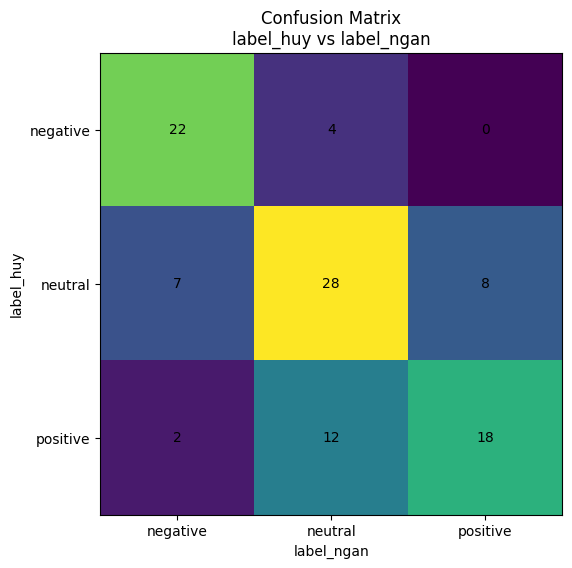

Saved: ../outputs/label_huy_label_choe.png


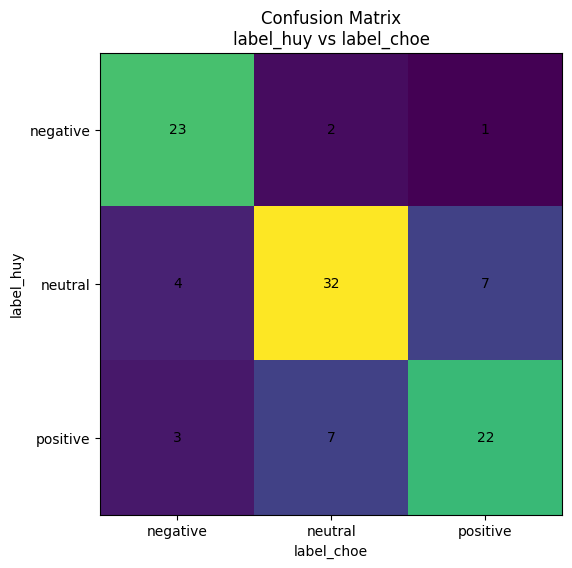

Saved: ../outputs/label_ngan_label_choe.png


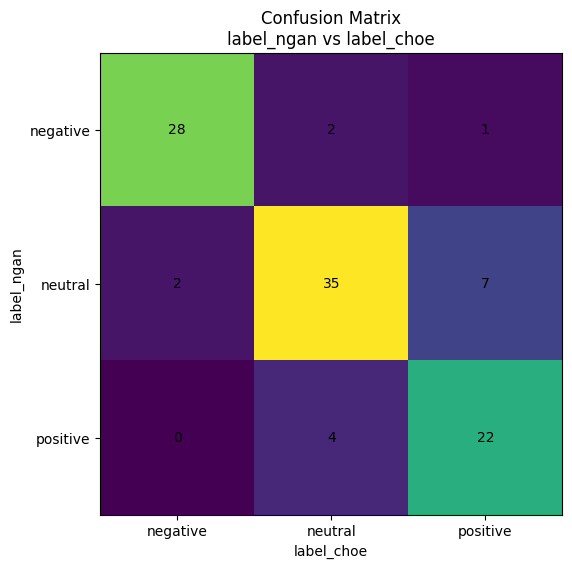

In [23]:
for a1, a2 in pairs:

    # Tính kết quả
    result = manual_cohen_kappa(
        df[a1],
        df[a2]
    )

    cm = result['confusion_matrix']
    labels = result['labels']

    # Tạo figure mới
    fig, ax = plt.subplots(figsize=(6, 6))

    im = ax.imshow(cm)

    # Tick labels
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))

    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    # Axis labels
    plt.xlabel(a2)
    plt.ylabel(a1)

    # Hiển thị số trong từng ô
    for i in range(len(labels)):
        for j in range(len(labels)):

            ax.text(
                j,
                i,
                cm[i, j],
                ha='center',
                va='center'
            )

    # Title
    plt.title(f"Confusion Matrix\n{a1} vs {a2}")

    # Save figure
    filename = f"{a1}_{a2}.png"

    output_path = f"../outputs/{filename}"

    plt.savefig(output_path)

    print(f"Saved: {output_path}")

    plt.show()

    # Đóng figure để tránh overwrite
    plt.close()

# Conclusion

Notebook này đã:

1. Merge annotation results
2. Tính pairwise Cohen’s Kappa
3. Tự code công thức Po, Pe, Kappa
4. Verify với sklearn
5. Phân tích disagreement
6. Visualization confusion matrix

Kết quả giúp đánh giá:
- mức độ đồng thuận giữa annotators
- độ tin cậy của annotation process
- chất lượng guideline labeling